In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
import re
import ast
from scipy.integrate import solve_ivp
from pathlib import Path

In [ ]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from configuration.initialize import *
from data.load_experiment import load_aux_data_exp

hfr_path = project_root / "data" / "HFR.xlsx"
xls = pd.ExcelFile(hfr_path)

# Simulation report
This manuscript is dedicated to compare the simulation result of massflow for dynamic and static model. The polarization curve was obtained by a static current profile

In [3]:
I_points = [10, 20, 30, 35, 40, 45, 50]

dyn_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass

            states_dyn_log = []
            time_evolutions = []
            massflow_dyn_log = []

            for I_LOAD in I_points:
                # --------------- Dynamic Simulation  --------------- #
                operating_inputs["Phi_c_des"] = RHC 
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["Tfc"] = T_des + 273.15
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                x_init = init_x(operating_inputs, parameters)
                model = PEMFC_dyn(parameters,operating_inputs, x_init)
                sol = solve_ivp(model.dxdt, (0, 60), x_init, method='BDF', max_step=1e-1)
                model._recovery(sol)
                # --------------- Log states for dynamic simulation  --------------- #
                states = {} # Log the last state values for each variable => pseudo steady-state values 
                time_evo = {} # Log the time evolution of each variable => check for convergence to steady-state
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                    time_evo[var_name] = model.variables[var_name]
                for key, var_name in enumerate(model.elec_variables):
                    states[var_name] = model.elec_variables[var_name][-1]
                    time_evo[var_name] = model.elec_variables[var_name]
                massflow_dyn = model.calculate_flows(sol.t[-1], states)

                states_dyn_log.append(states)
                time_evolutions.append(time_evo)
                massflow_dyn_log.append(massflow_dyn)
                
            # --------------- Log states profile for both simulations  --------------- #
            states_profile_dyn = {}
            for key, value in enumerate(states_dyn_log[0].keys()):
                states_profile_dyn[value] = [states[value] for states in states_dyn_log]
            dyn_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile_dyn, "time_evolution":time_evolutions, "massflow": massflow_dyn_log}

Before comparing the simulation result, the convergency of the state variable in the dynamic model should be verified at a time constant such as 90 seconds.

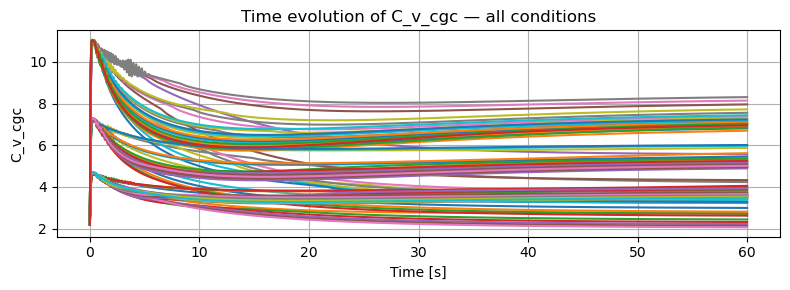

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))

for cond_key, cond_data in dyn_log_all.items():
    for j, I in enumerate(I_points):
        te = cond_data["time_evolution"][j]
        ax.plot(te["t"], te["C_v_cgc"], label=f"{cond_key}, I={I}A")

ax.set_xlabel("Time [s]")
ax.set_ylabel("C_v_cgc")
ax.set_title("Time evolution of C_v_cgc — all conditions")
ax.grid(True)
fig.tight_layout()
plt.show()

It's obvious that the vapor concentration in the gas channel stablized at around 40 seconds, which indicated that the net vapor flow from CL to GC is stablized

In [5]:
stat_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass
            states_stat = []
            for I_LOAD in I_points:
                # --------------- Steady-state Simulation  --------------- #
                Wout_c = 10 + I_LOAD * 2.
                Win_c = 1 + I_LOAD *2.5
                Wout_a = 10 + I_LOAD * 3
                operating_inputs_stat = {'Tfc': T_des + 273.15, 'Phi_a_des': 0, 'Phi_c_des': RHC,
                                                             'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                             'Win_c': Win_c, 'Wout_c': Wout_c, 'Win_a': 0, 'Wout_a': Wout_a}
                model = PEMFC_stat(parameters,operating_inputs_stat)
                sol = model.solve(I_LOAD/parameters['Aact'])
                # --------------- Log states for steady-state simulation  --------------- #
                states_stat.append(sol)
            # --------------- Log states for both simulations  --------------- #
            stat_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

In [6]:
aux_data_exp = load_aux_data_exp(project_root, stat_log_all, dyn_log_all, I_points)
loaded = sum(bool(v.get("states")) for v in aux_data_exp.values())

The inlet velocity is the critical role in defining the boundary condition of gas profile in the MEA. The supply manifold is regarded as the pressure regulator in the dynamic model. The inlet velocity of the dry air and hydrogen are matched with the experiment data. For the static model the inlet velocity will match the outlet velocity of the supply manifold on both side.

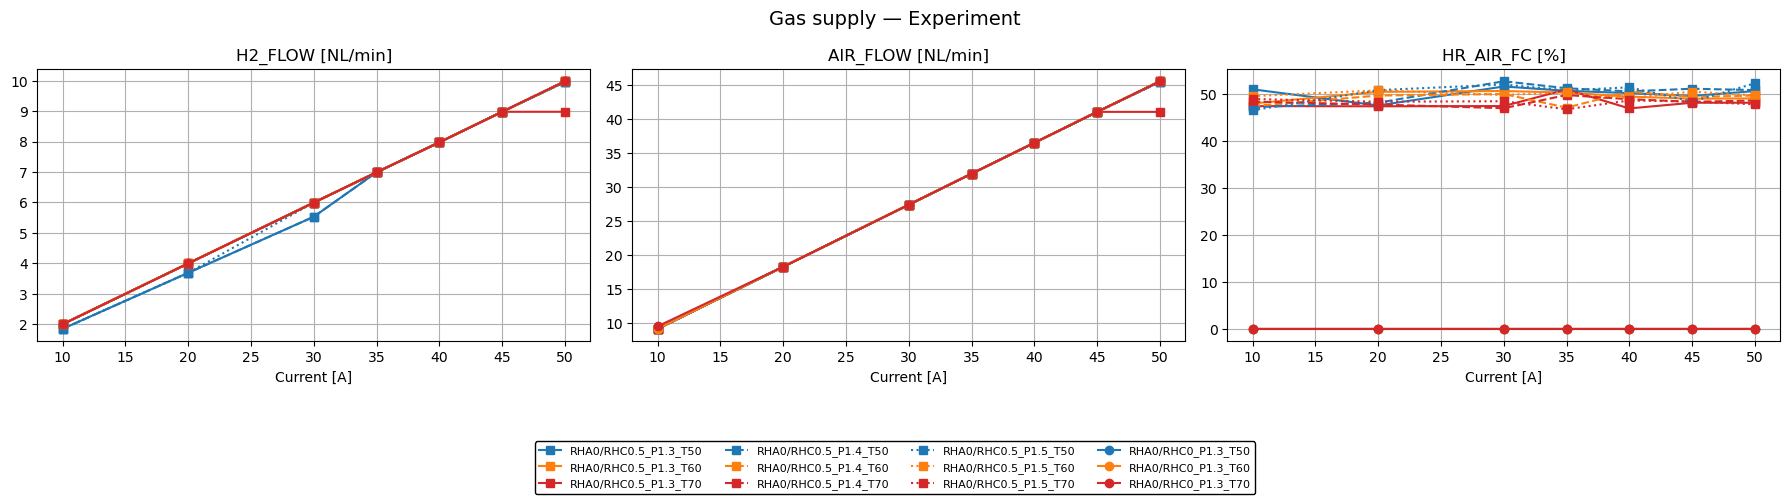

In [7]:
cols_to_plot = [("H2_FLOW", "H2_FLOW [NL/min]"), ("AIR_FLOW", "AIR_FLOW [NL/min]"),  ("HR_AIR_FC", "HR_AIR_FC [%]")]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
fig.suptitle("Gas supply — Experiment", fontsize=14)
handles, labels = [], [] 
for key in aux_data_exp.keys():
    props = get_plot_properties(key)
    exp_states = aux_data_exp[key].get("states", {})
    line = None
    for ax, (col, col_label) in zip(axes.flatten(), cols_to_plot):
        if col in exp_states:
            l, = ax.plot(I_points, exp_states[col], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
            if line is None:
                line = l
    if line is None:  # condition had no data — add dummy handle for legend completeness
        line, = axes[0].plot([], [], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)
for ax, (col, col_label) in zip(axes.flatten(), cols_to_plot):
    ax.set_title(col_label)
    ax.set_xlabel("Current [A]")
    ax.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                 ncol=4, fontsize=8, frameon=True, facecolor='white',
                 edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()

And the figure above demonstrate the simulated gas supply actuator of the dynamic model:

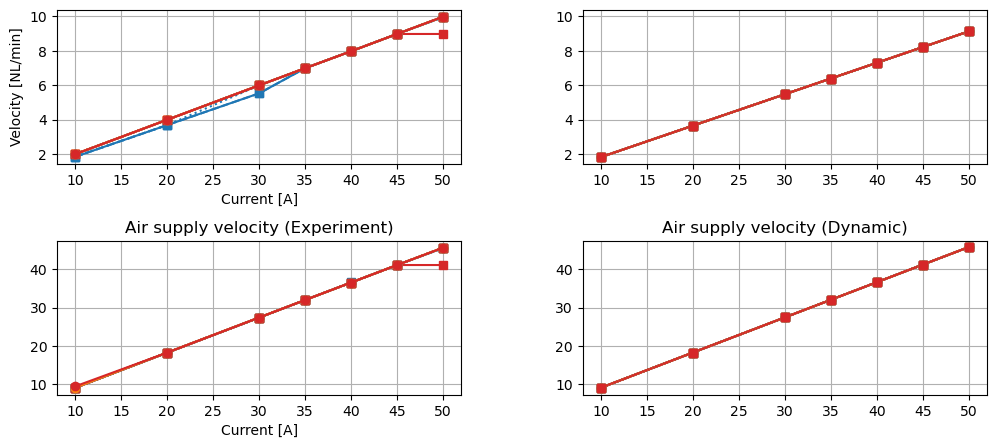

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for key in aux_data_exp.keys():
    props = get_plot_properties(key)
    exp_states = aux_data_exp[key].get("states", {})
    axes[0, 0].plot(I_points,  exp_states["H2_FLOW"], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1, 0].plot(I_points, exp_states["AIR_FLOW"], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
for cond_key, cond_data in dyn_log_all.items():
    props = get_plot_properties(cond_key)
    states = cond_data["states"]
    Wcp_NLmin = np.array(states["Wcp"])/2.155e-5 # V_NLMIN * M_O2/(Vm_std*60)
    Wrd_NLmin = np.array(states["Wasm_in"])/1.499e-6 # V_NLMIN * M_H2/(Vm_std*60)
    axes[1, 1].plot(I_points, Wcp_NLmin, color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0, 1].plot(I_points, Wrd_NLmin, color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
axes[0, 1].set_ylim(axes[0, 0].get_ylim()); axes[0,1].grid(True)
axes[1, 1].set_ylim(axes[1, 0].get_ylim()); axes[1,1].grid(True)
axes[1, 0].set_title("Air supply velocity (Experiment)"); axes[1, 0].set_xlabel("Current [A]"); axes[1, 0].grid(True)
axes[0, 0].set_ylabel("Velocity [NL/min]");
axes[1, 1].set_title("Air supply velocity (Dynamic)"); axes[0, 0].set_xlabel("Current [A]"); axes[0, 0].grid(True)

### Cathode Gas Channel

#### Static Model (Algebraic)

In steady-state operation, the gas channel concentrations are computed algebraically from mass balance, assuming instantaneous equilibrium:

**Vapor Concentration ($C_{v,cgc}$) - Static:**
$$C_{v,cgc} = \frac{J_w L_{gc}/H_{gc} + C_{v,in} W_{in}}{W_{out}}$$

Where:
- $J_w$ = net vapor flow from CL (positive direction: CL -> GC)
- $C_{v,in}$ = inlet vapor concentration
- $W_{in}$, $W_{out}$ = inlet/outlet mass flow rates
- $P_c$ = cathode pressure

In the figure below, the massflow of static model $J_{v,c}(mol/(m^3\cdot s))$ is presented:
$$J_{v,c} = W_{in,c} * \Phi_{a, des} * C_{v,sat}(T_{fc})/L_{gc}$$

#### Dynamic Model (PDE)

The dynamic model tracks time-evolving concentrations accounting for inlet/outlet flows and GDL exchange:

**Vapor Concentration ($C_{v,cgc}$) - Dynamic ODE:**
$$\frac{dC_{v,cgc}}{dt} = \frac{J_{v,c,in} - J_{v,c,out}}{L_{gc}} + \frac{J_{v,cgdl \to cgc}}{H_{gc}}$$

Where:
- $J_{v,c,in}$, $J_{v,c,out}$ = inlet/outlet vapor molar fluxes [mol/(m²·s)]
- $J_{v,cgdl \to cgc}$, $J_{O_2,cgdl \to cgc}$ = molar fluxes from GDL to CGC [mol/(m²·s)]
- $L_{gc}$ = gas channel length [m]
- $H_{gc}$ = gas channel height [m]

**Key Difference:** The dynamic model accounts for transient accumulation of vapor and oxygen in the channel, making it sensitive to control input changes (humidity, inlet flow), while the static model assumes quasi-steady behavior.

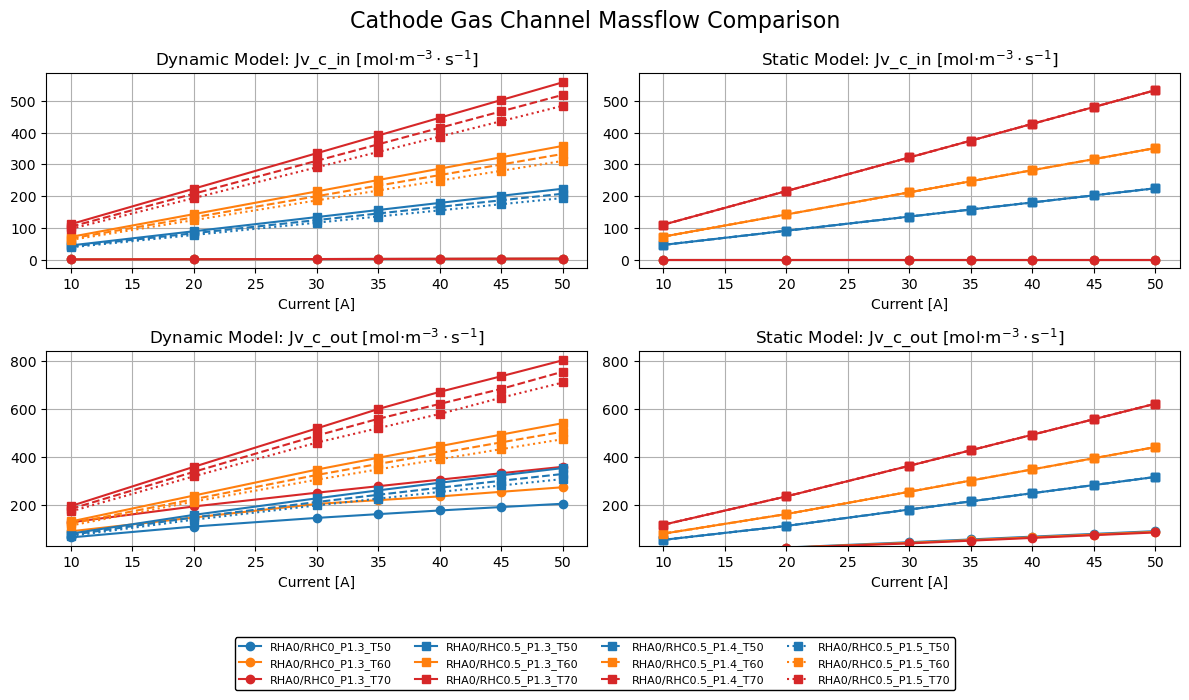

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))
fig.suptitle("Cathode Gas Channel Massflow Comparison", fontsize=16)
Vm_STP = R * 273.15 / 101325
V_gc_total = n_cell * parameters["Hgc"] * parameters["Wgc"] * parameters["Lgc"]


handles, labels = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    line, = axes[0,0].plot(I_points, [massflow["Jv_c_in"] for massflow in massflow_dyn],
                                       color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0,1].plot(I_points, [states["Jv_c_in"] for states in states_stat],
                   color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,0].plot(I_points, [massflow["Jv_c_out"] for massflow in massflow_dyn],
                           color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,1].plot(I_points, [states["Jv_c_out"] for states in states_stat],
                           color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)

axes[0,0].set_title(r"Dynamic Model: Jv_c_in [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[0,0].set_xlabel("Current [A]"); axes[0,0].grid(True)
axes[0,1].set_title(r"Static Model: Jv_c_in [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[0,1].set_xlabel("Current [A]"); axes[0,1].grid(True)
axes[0,1].set_ylim(axes[0,0].get_ylim())
axes[1,1].set_ylim(axes[1,0].get_ylim())
axes[1,0].set_title(r"Dynamic Model: Jv_c_out [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[1,0].set_xlabel("Current [A]"); axes[1,0].grid(True)
axes[1,1].set_title(r"Static Model: Jv_c_out [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[1,1].set_xlabel("Current [A]"); axes[1,1].grid(True)

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                  ncol=4, fontsize=8, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

### Remark
The measurement of the vapor inlet is constant because the sensor is before the supply manifold. The $J_{v,in}$ and $J_{v, out}$ in this case refers to the velocity after the manifold

## Match the Hydrogen inlet velocity

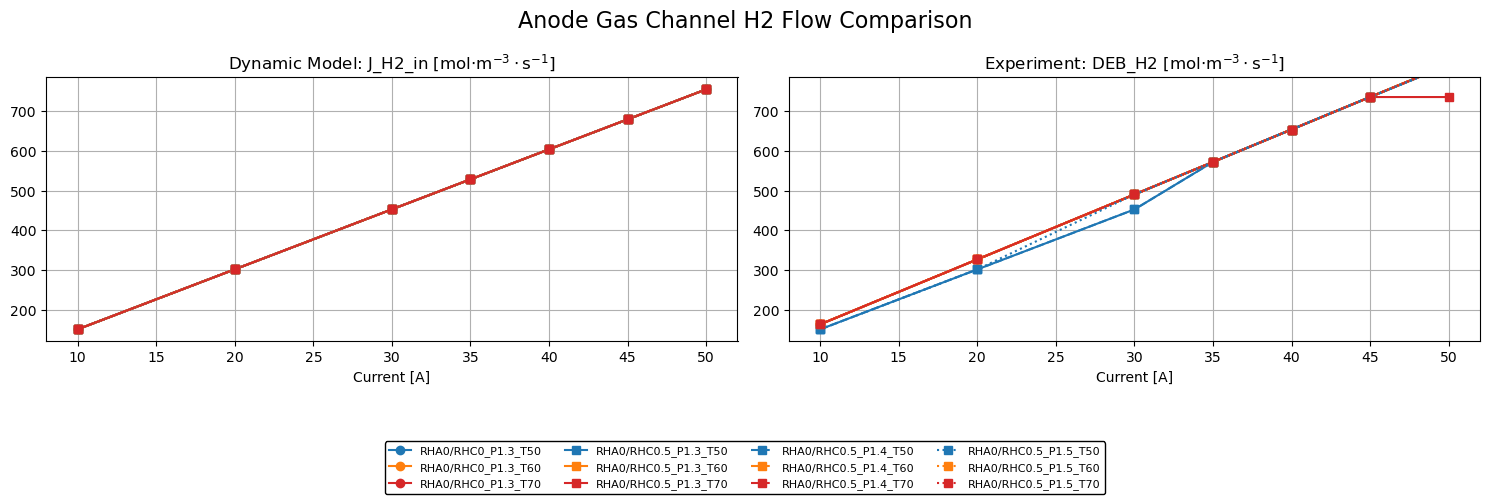

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle("Anode Gas Channel H2 Flow Comparison", fontsize=16)
Vm_STP = R * 273.15 / 101325
V_gc_total = n_cell * parameters["Hgc"] * parameters["Wgc"] * parameters["Lgc"]
conv_DEB_H2 = 1e-3 / 60 / Vm_STP / V_gc_total

handles, labels = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    massflow_dyn = dyn_log_all[key]["massflow"]

    line, = axes[0].plot(I_points, [massflow["J_H2_in"]/parameters["Lgc"] for massflow in massflow_dyn],
                         color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    exp_states = aux_data_exp.get(key, {}).get("states", {})
    if "DEB_H2*" in exp_states:
        axes[1].plot(I_points, [v * conv_DEB_H2 for v in exp_states["DEB_H2*"]],
                     color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)

axes[0].set_title(r"Dynamic Model: J_H2_in [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[0].set_xlabel("Current [A]"); axes[0].grid(True)
axes[1].set_title(r"Experiment: DEB_H2 [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[1].set_xlabel("Current [A]"); axes[1].set_ylim(axes[0].get_ylim()); axes[1].grid(True)

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
           ncol=4, fontsize=8, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()

### Anode Gas Channel Vapor Concentration Result (Static vs Dynamic)

This section focuses only on anode gas channel vapor concentration, $C_{v,agc}$.

Dynamic model result:
- $C_{v,agc}$ changes with time before reaching a stable value for each operating point.
- At higher load, the final $C_{v,agc}$ level is generally higher because water generation is stronger.
- Changes in operating condition (pressure/humidity setpoint) affect both the transient response speed and the final concentration level.

Static model result:
- The model gives one steady-state value of $C_{v,agc}$ per operating point (no transient trajectory).
- These values represent equilibrium vapor concentration in the anode gas channel.

Comparison insight:
- Static results correspond to the final equilibrium level.
- Dynamic results add the transient path toward that level, which is important for startup and load-change analysis.

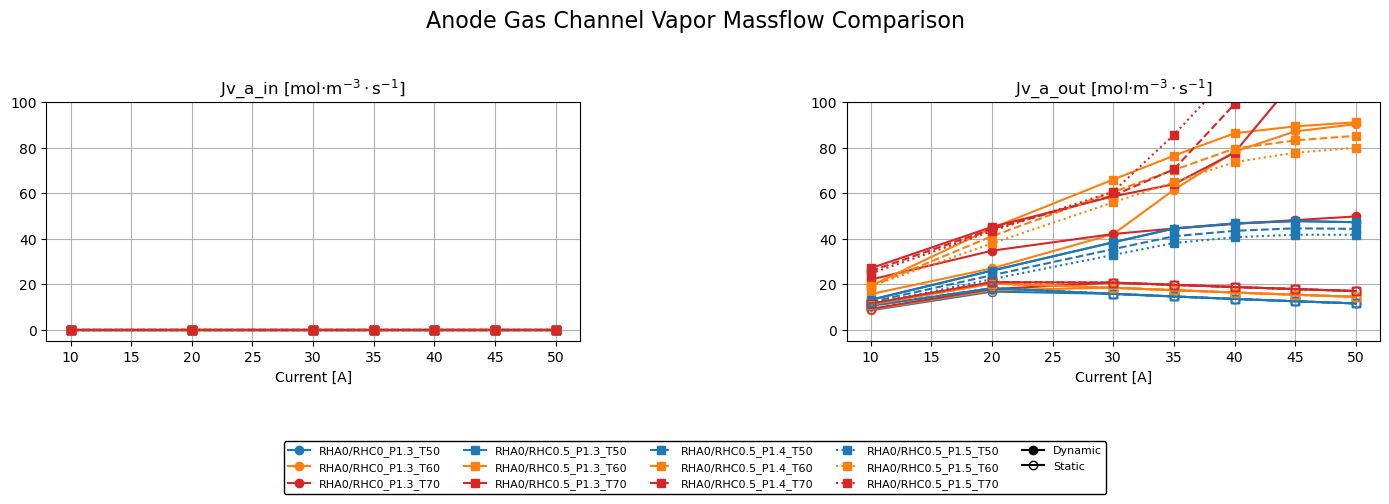

In [11]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
fig.suptitle("Anode Gas Channel Vapor Massflow Comparison", fontsize=16)

handles_cond, labels_cond = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    # Dynamic: filled markers
    line, = axes[0].plot(I_points, [massflow["Jv_a_in"] for massflow in massflow_dyn],
                         color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1].plot(I_points, [massflow["Jv_a_out"] for massflow in massflow_dyn],
                 color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    # Static: open markers
    axes[0].plot(I_points, [states["Jv_a_in"] for states in states_stat],
                 color=props['color'], linestyle=props['linestyle'], marker=props['marker'],
                 markerfacecolor='none')
    axes[1].plot(I_points, [states["Jv_a_out"] for states in states_stat],
                 color=props['color'], linestyle=props['linestyle'], marker=props['marker'],
                 markerfacecolor='none')
    handles_cond.append(line)
    labels_cond.append(key)

legend_models = [
    Line2D([0], [0], color='k', marker='o', linestyle='-', label='Dynamic'),
    Line2D([0], [0], color='k', marker='o', linestyle='-', markerfacecolor='none', label='Static'),
]

axes[0].set_title(r"Jv_a_in [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[0].set_xlabel("Current [A]"); axes[0].grid(True)
axes[1].set_title(r"Jv_a_out [mol$\cdot$m$^{-3}\cdot$s$^{-1}$]"); axes[1].set_xlabel("Current [A]"); axes[1].grid(True)
for ax in axes:
    ax.set_ylim(-5, 100)

fig.legend(handles_cond + legend_models, labels_cond + ['Dynamic', 'Static'],
           loc='lower center', bbox_to_anchor=(0.5, 0),
           ncol=5, fontsize=8, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.2, 1, 0.95])
plt.subplots_adjust(wspace=0.5)
plt.show()

### GDL Massflow Comparison (Anode vs Cathode)

The equations below are the GDL state equations used in this project (from `model/dynamic.py`, `model/static.py`, and summarized in `README.md`).

#### Dynamic model (state equations)
For each GDL node $i$:

$$\frac{dC_{v,gdl,i}}{dt}=\frac{1}{\varepsilon_{gdl}(1-s_i)}\left(\frac{J_{v,i-1}-J_{v,i}}{\Delta x_{gdl}}+S_{v,i}\right)$$

$$\frac{dC_{v,gdl,i}}{dt}=\frac{1}{\varepsilon_{gdl}(1-s_i)}\left(\frac{J_{v,i-1}-J_{v,i}}{\Delta x_{gdl}}\right)$$

$$\frac{ds_{gdl,i}}{dt}=\frac{1}{\rho_{H_2O}\,\varepsilon_{gdl}}\left(\frac{J_{l,i-1}-J_{l,i}}{\Delta x_{gdl}}+M_{H_2O}S_{l,i}\right)$$

In code, the plotted dynamic GDL liquid fluxes are:
- Anode side: `Jl_agdl_acl`
- Cathode side: `Jl_ccl_cgdl`

#### Static model (algebraic equations)
No time derivative is solved in the static model. The GDL is computed from algebraic profiles:

$$C_{v,gdl}(x)=C_{v,inter}+\frac{x}{D_{eff}}J_w$$

$$C_{v,gdl}(x)=C_{v,inter}+\frac{x}{D_{eff}(s)}J_{v}$$

Saturation is obtained from Leverett-type inversion in `gdl_profile(...)` (via `self._solve_sat(...)`), with front tracking by:

$$x_{front}=\frac{(C_{v,sat}-C_{v,inter})D_{eff}}{J_w}$$

In the static results used in the plot:
- Anode-side water flux proxy: `Jw_an`
- Cathode-side water flux proxy: `Jw_ca`

So this figure compares dynamic GDL transport fluxes against their static algebraic counterparts for both anode and cathode.

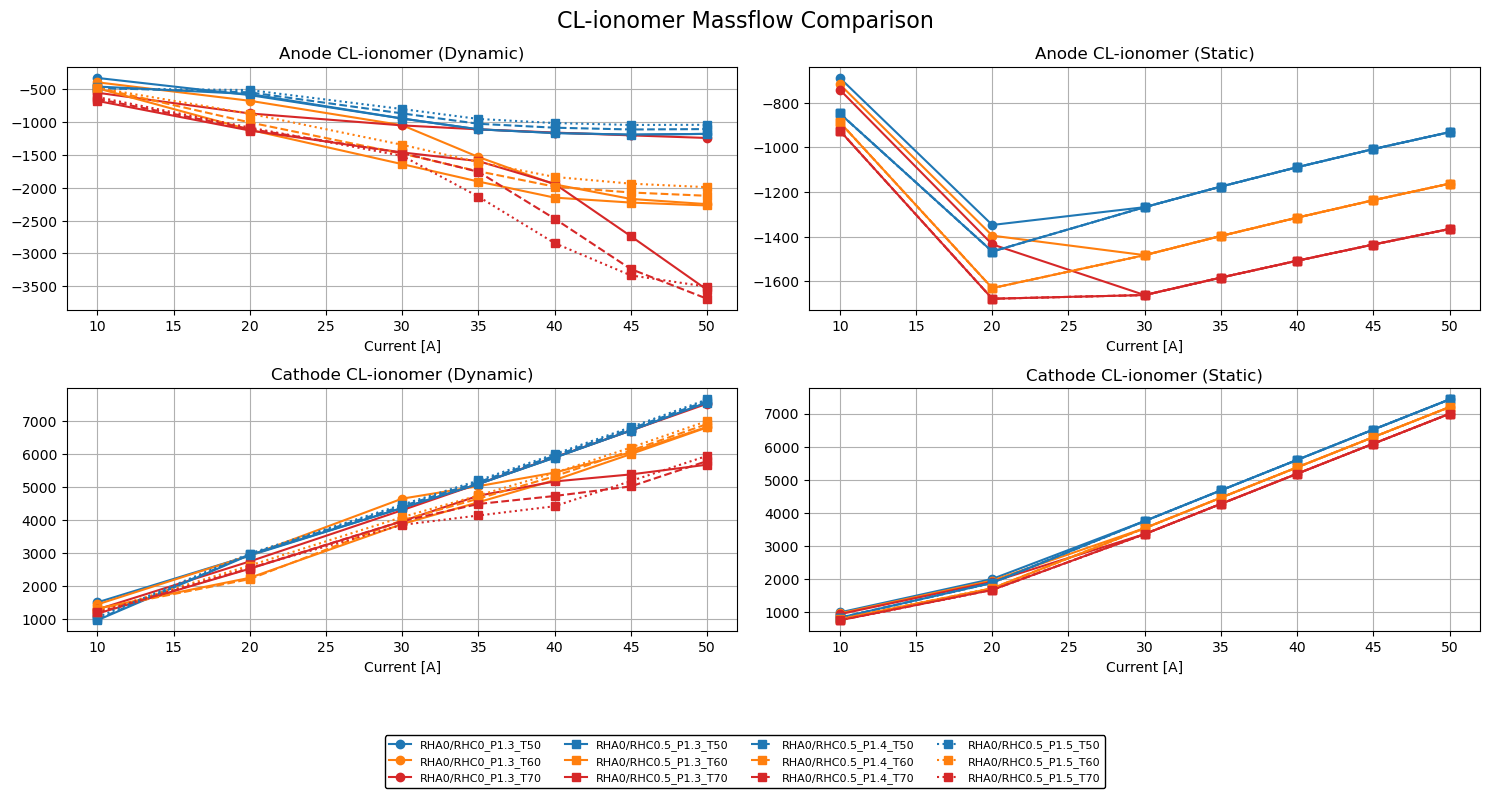

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
fig.suptitle("CL-ionomer Massflow Comparison", fontsize=16)

handles, labels = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    line, = axes[0,0].plot(I_points, [massflow["S_sorp_acl"] for massflow in massflow_dyn],
                           color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0,1].plot(I_points, [-states["Jw_an"]/parameters["Hcl"] for states in states_stat],
                   color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,0].plot(I_points, [-massflow["S_sorp_ccl"] for massflow in massflow_dyn],
                   color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,1].plot(I_points, [states["Jw_ca"]/parameters["Hcl"] for states in states_stat],
                   color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)

axes[0,0].set_title("Anode CL-ionomer (Dynamic)"); axes[0,0].set_xlabel("Current [A]"); 
axes[0,0].grid(True)
axes[0,1].set_title("Anode CL-ionomer (Static)"); axes[0,1].set_xlabel("Current [A]")
#axes[0,1].set_ylim(axes[0,0].get_ylim())
axes[0,1].grid(True)
axes[1,0].set_title("Cathode CL-ionomer (Dynamic)"); axes[1,0].set_xlabel("Current [A]"); axes[1,0].grid(True)
axes[1,1].set_title("Cathode CL-ionomer (Static)"); axes[1,1].set_xlabel("Current [A]")
#axes[1,1].set_ylim(axes[1,0].get_ylim())
axes[1,1].grid(True)

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                  ncol=4, fontsize=8, frameon=True, facecolor='white',
                  edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

### Membrane Massflow Comparison (Anode vs Cathode)

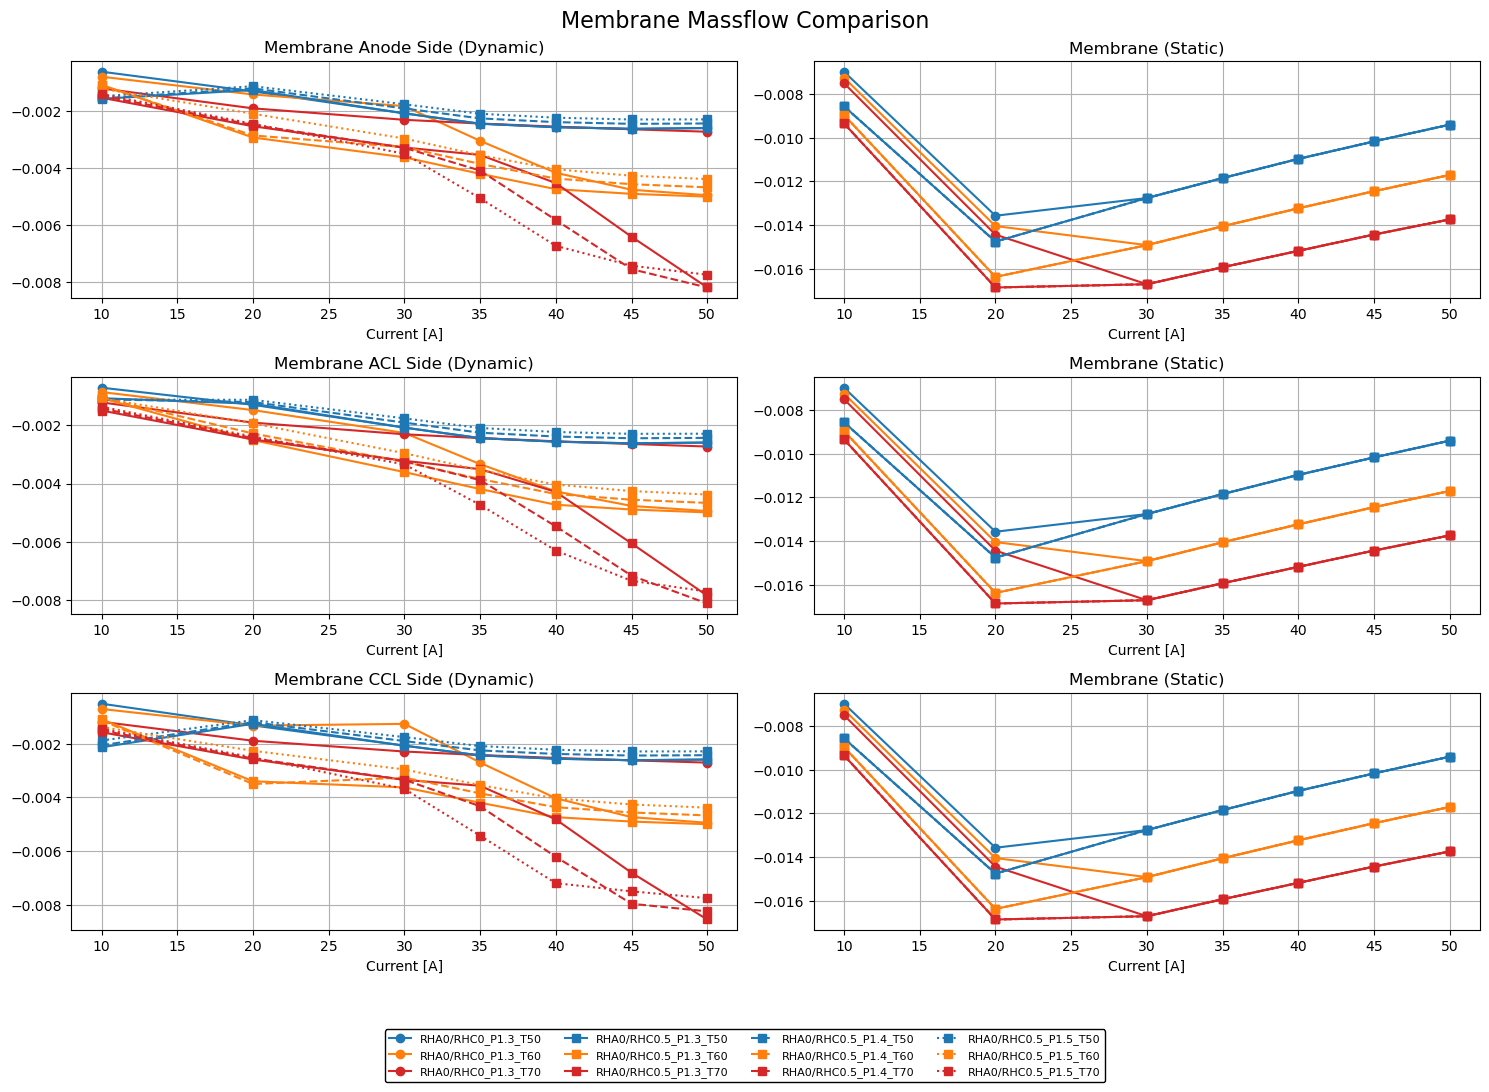

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 11))
fig.suptitle("Membrane Massflow Comparison", fontsize=16)

handles, labels = [], []
for key in dyn_log_all.keys():
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    line, = axes[0,0].plot(I_points, [np.mean(massflow["J_lambda_mem"]) for massflow in massflow_dyn],
                                       color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[0,1].plot(I_points, [-states["Jmem"] for states in states_stat],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,0].plot(I_points, [massflow["J_lambda_mem_acl"] for massflow in massflow_dyn],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[1,1].plot(I_points, [-states["Jmem"] for states in states_stat],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[2,0].plot(I_points, [massflow["J_lambda_mem_ccl"] for massflow in massflow_dyn],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    axes[2,1].plot(I_points, [-states["Jmem"] for states in states_stat],
                            color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)

axes[0,0].set_title("Membrane Anode Side (Dynamic)"); axes[0,0].set_xlabel("Current [A]"); axes[0,0].grid(True)
axes[0,1].set_title("Membrane (Static)"); axes[0,1].set_xlabel("Current [A]")
axes[0,1].grid(True)
axes[1,0].set_title("Membrane ACL Side (Dynamic)"); axes[1,0].set_xlabel("Current [A]"); axes[1,0].grid(True)
axes[1,1].set_title("Membrane (Static)"); axes[1,1].set_xlabel("Current [A]"); 
axes[1,1].grid(True)
axes[2,0].set_title("Membrane CCL Side (Dynamic)"); axes[2,0].set_xlabel("Current [A]"); axes[2,0].grid(True)
axes[2,1].set_title("Membrane (Static)"); axes[2,1].set_xlabel("Current [A]"); 
axes[2,1].grid(True)

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                  ncol=4, fontsize=8, frameon=True, facecolor='white', 
                  edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.show()

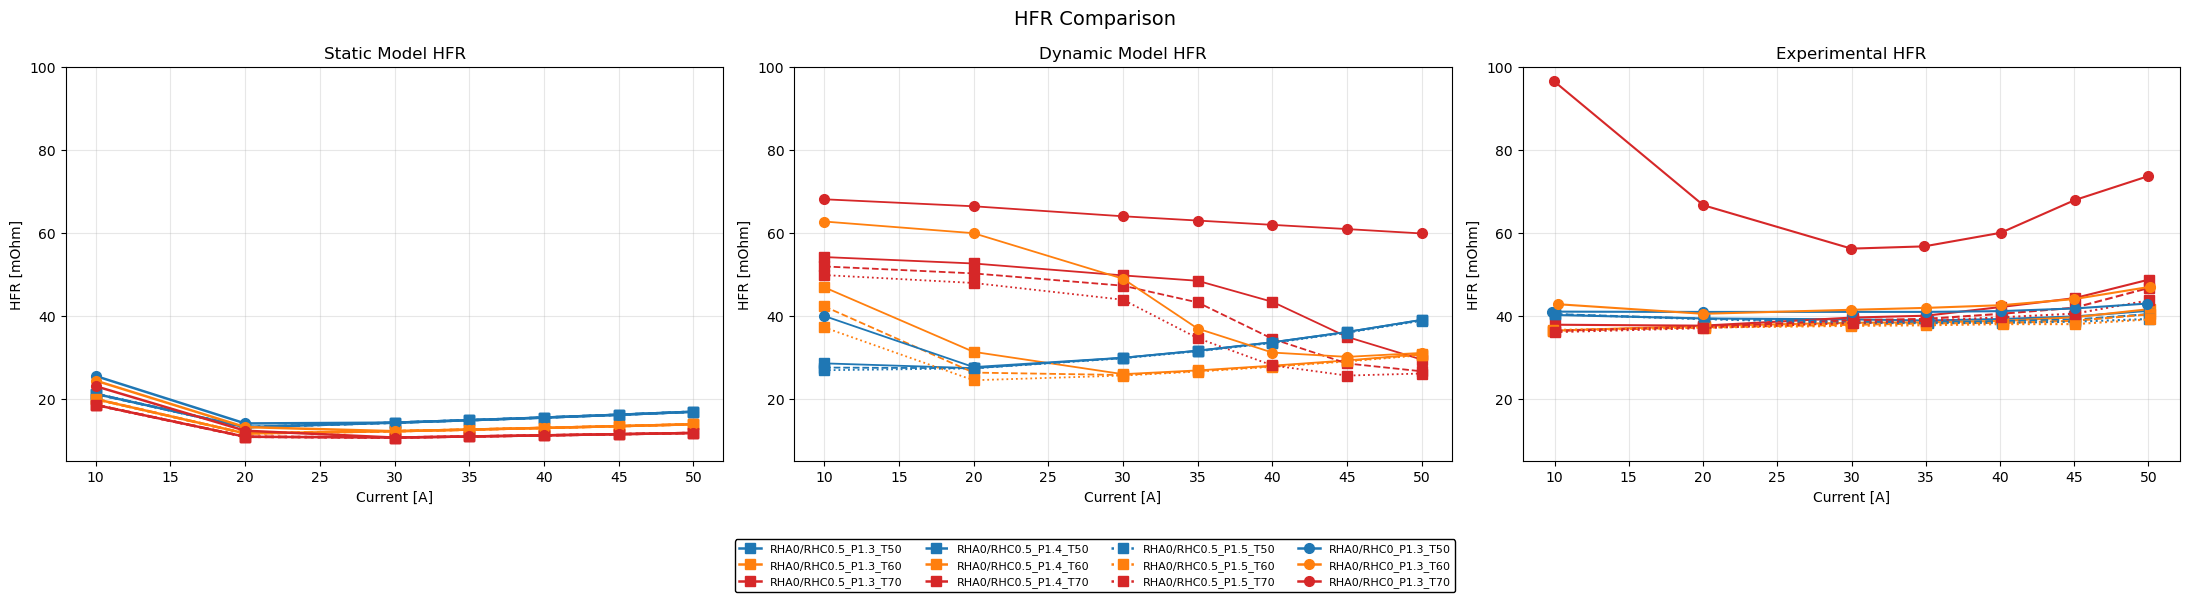

In [ ]:
exp_hfr_by_cond = {}
for sheet in xls.sheet_names:
    df = pd.read_excel(hfr_path, sheet_name=sheet)
    if ("I_LOAD" not in df.columns) or ("R" not in df.columns):
        continue

    m = re.match(r"T(\d+)_P(\d+)_HRC(\d+)", sheet)
    if not m:
        continue

    t_val = int(m.group(1))
    p_tag = int(m.group(2))
    hrc_tag = int(m.group(3))
    p_val = 1.0 + p_tag / 1000.0
    rhc_val = hrc_tag / 100.0
    cond_key = f"RHA0/RHC{rhc_val:g}_P{p_val:.1f}_T{t_val}"

    x_exp = df["I_LOAD"].to_numpy(dtype=float)
    y_exp = np.array([ast.literal_eval(v)[0] if isinstance(v, str) else v for v in df["R"]], dtype=float)
    exp_hfr_by_cond[cond_key] = {"x": x_exp, "y": y_exp}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("HFR Comparison", fontsize=14)
ax_static, ax_dynamic, ax_exp = axes

handles, labels = [], []
for key in sorted(dyn_log_all.keys()):
    props = get_plot_properties(key)
    states_stat = stat_log_all[key]["states"]
    states_dyn = dyn_log_all[key]["states"]

    hfr_static = np.array([states["Rohm"] / parameters["Aact"] * n_cell * 1e3 for states in states_stat], dtype=float)
    hfr_dynamic = np.array([(sum(rmem) + parameters["Re"]) / parameters["Aact"] * n_cell * 1e3 for rmem in states_dyn["Rmem"]], dtype=float)
    hfr_dynamic += np.array([(rmem) / parameters["Aact"] * n_cell * 1e3 for rmem in states_dyn["Rccl"]], dtype=float)/2
    hfr_dynamic += np.array([(rmem) / parameters["Aact"] * n_cell * 1e3 for rmem in states_dyn["Racl"]], dtype=float)/2

    line, = ax_static.plot(I_points, hfr_static, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.8, markersize=7, label=key)
    ax_dynamic.plot(I_points, hfr_dynamic, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.3, markersize=7)
    handles.append(line)
    labels.append(key)

    if key in exp_hfr_by_cond:
        x_exp = exp_hfr_by_cond[key]["x"]
        y_exp = exp_hfr_by_cond[key]["y"]
        ax_exp.plot(x_exp, y_exp, color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, markersize=7)

ax_exp.set_title("Experimental HFR")
ax_exp.set_xlabel("Current [A]")
ax_exp.set_ylabel("HFR [mOhm]")
ax_exp.grid(True, alpha=0.3)
ax_exp.set_ylim(5, 100)  # Ensure y-limits can accommodate experimental data
ax_static.set_title("Static Model HFR")
ax_static.set_xlabel("Current [A]")
ax_static.set_ylabel("HFR [mOhm]")
ax_static.grid(True, alpha=0.3)
ax_static.set_ylim(ax_exp.get_ylim())
ax_dynamic.set_title("Dynamic Model HFR")
ax_dynamic.set_xlabel("Current [A]")
ax_dynamic.set_ylabel("HFR [mOhm]")
ax_dynamic.grid(True, alpha=0.3)
ax_dynamic.set_ylim(ax_exp.get_ylim())

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0), ncol=4, fontsize=8, frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)

plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()